In [2]:
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
#from sklearn.datasets import load_boston
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [18]:
import pandas as pd

data = pd.read_csv("boston_housing.csv")
print(data.head())


      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD    TAX  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296.0   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242.0   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242.0   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222.0   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222.0   

   PTRATIO       B  LSTAT  MEDV  
0     15.3  396.90   4.98  24.0  
1     17.8  396.90   9.14  21.6  
2     17.8  392.83   4.03  34.7  
3     18.7  394.63   2.94  33.4  
4     18.7  396.90   5.33  36.2  


In [19]:
data.keys()

Index(['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX',
       'PTRATIO', 'B', 'LSTAT', 'MEDV'],
      dtype='str')

In [20]:
#data = pd.DataFrame(data=boston.data, columns=boston.feature_names)
data.tail()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
395,0.09065,20.0,6.96,1,0.464,5.920,61.5,3.9175,3,223.0,18.6,391.34,13.65,20.7
396,0.29916,20.0,6.96,0,0.464,5.856,42.1,4.4290,3,223.0,18.6,388.65,13.00,21.1
397,0.16211,20.0,6.96,0,0.464,6.240,16.3,4.4290,3,223.0,18.6,396.90,6.59,25.2
398,0.11460,20.0,6.96,0,0.464,6.538,58.7,3.9175,3,223.0,18.6,394.96,7.73,24.4
399,0.22188,20.0,6.96,1,0.464,7.691,51.8,4.3665,3,223.0,18.6,390.77,6.58,35.2


In [21]:
data.sample(6)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
38,0.17505,0.0,5.96,0,0.499,5.966,30.2,3.8473,5,279.0,19.2,393.43,10.13,24.7
277,0.06127,40.0,6.41,1,0.447,6.826,27.6,4.8628,4,254.0,17.6,393.45,4.16,33.1
165,2.92400,0.0,19.58,0,0.605,6.101,93.0,2.2834,5,403.0,14.7,240.16,9.81,25.0
133,0.32982,0.0,21.89,0,0.624,5.822,95.4,2.4699,4,437.0,21.2,388.69,15.03,18.4
140,0.29090,0.0,21.89,0,0.624,6.174,93.6,1.6119,4,437.0,21.2,388.08,24.16,14.0
202,0.02177,82.5,2.03,0,0.415,7.610,15.7,6.2700,2,348.0,14.7,395.38,3.11,42.3


In [22]:
data.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000
mean,0.400492,15.421250,8.329100,0.137500,0.509467,6.522088,62.117250,4.279300,4.680000,304.582500,17.469000,380.963775,10.444750,26.886250
std,0.592608,25.251257,5.770709,0.344806,0.098462,0.779224,28.816459,1.940831,1.844208,63.710641,2.193734,37.973781,6.198467,9.324729
min,0.006320,0.000000,0.460000,0.000000,0.385000,4.903000,2.900000,1.321600,1.000000,188.000000,12.600000,70.800000,1.730000,11.800000
25%,0.078908,0.000000,4.050000,0.000000,0.438500,5.951000,35.500000,2.842500,4.000000,264.000000,16.400000,382.630000,5.515000,20.400000
50%,0.166705,0.000000,6.200000,0.000000,0.489000,6.373000,66.550000,3.877100,5.000000,300.000000,17.800000,391.600000,9.460000,24.000000
75%,0.475177,22.000000,10.590000,0.000000,0.538000,6.969750,88.650000,5.697275,5.000000,330.000000,18.700000,395.275000,13.620000,31.600000
max,4.097400,100.000000,25.650000,1.000000,0.871000,8.725000,100.000000,9.222900,8.000000,469.000000,21.200000,396.900000,34.410000,50.000000


In [23]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     400 non-null    float64
 1   ZN       400 non-null    float64
 2   INDUS    400 non-null    float64
 3   CHAS     400 non-null    int64  
 4   NOX      400 non-null    float64
 5   RM       400 non-null    float64
 6   AGE      400 non-null    float64
 7   DIS      400 non-null    float64
 8   RAD      400 non-null    int64  
 9   TAX      400 non-null    float64
 10  PTRATIO  400 non-null    float64
 11  B        400 non-null    float64
 12  LSTAT    400 non-null    float64
 13  MEDV     400 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 43.9 KB


In [24]:
data.isnull().sum()


CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64

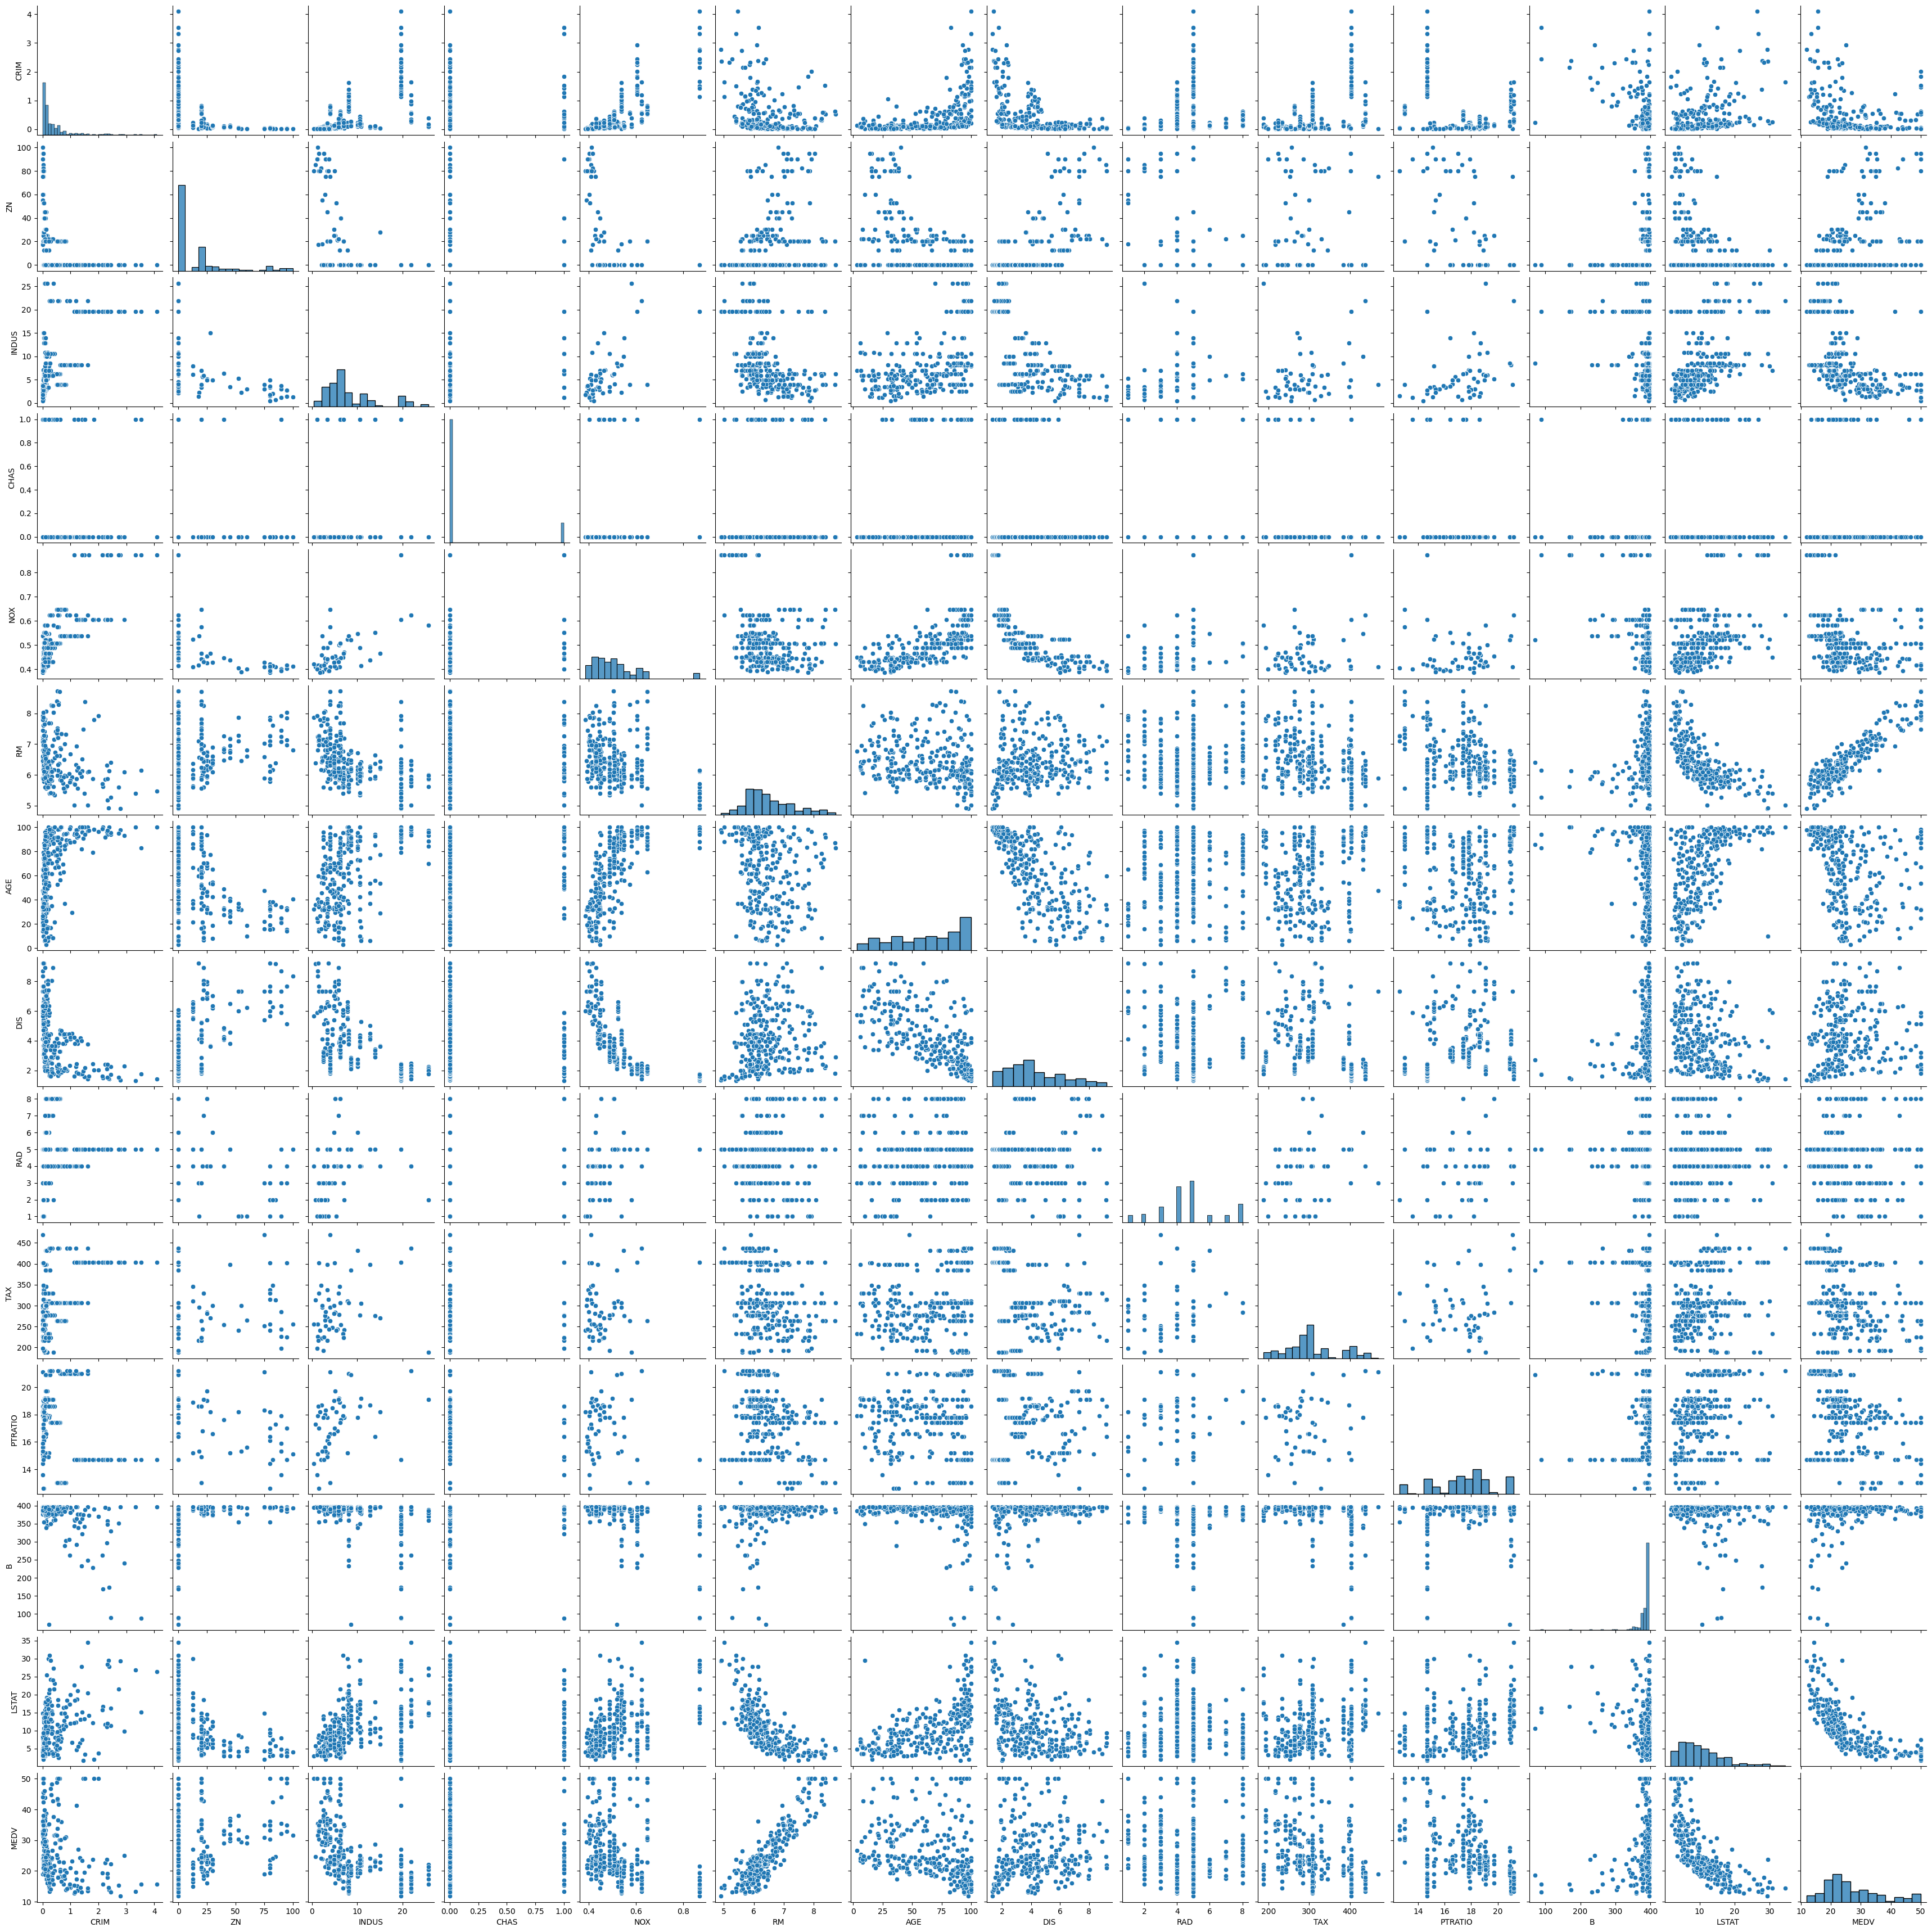

In [25]:
sns.pairplot(data)